# Data import

In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('merged_df.csv')

In [3]:
df.head()

,Unnamed: 0,time,generation biomass,generation fossil brown coal/lignite,generation fossil gas,generation fossil hard coal,generation fossil oil,generation hydro pumped storage consumption,generation hydro run-of-river and poundage,generation hydro water reservoir,...,total load forecast,total load actual,price day ahead,price actual,temp,humidity,pressure,wind_speed,rain_1h,clouds_all
0,0,2014-12-31 23:00:00,447.0,329.0,4844.0,4821.0,162.0,863.0,1051.0,1899.0,...,26118.0,25385.0,50.10,65.41,272.491463,82.4,1016.4,2.0,0.0,0.0
1,1,2015-01-01 00:00:00,449.0,328.0,5196.0,4755.0,158.0,920.0,1009.0,1658.0,...,24934.0,24382.0,48.10,64.92,272.512700,82.4,1016.2,2.0,0.0,0.0
2,2,2015-01-01 01:00:00,448.0,323.0,4857.0,4581.0,157.0,1164.0,973.0,1371.0,...,23515.0,22734.0,47.33,64.48,272.099137,82.0,1016.8,2.4,0.0,0.0
3,3,2015-01-01 02:00:00,438.0,254.0,4314.0,4131.0,160.0,1503.0,949.0,779.0,...,22642.0,21286.0,42.27,59.32,272.089469,82.0,1016.6,2.4,0.0,0.0
4,4,2015-01-01 03:00:00,428.0,187.0,4130.0,3840.0,156.0,1826.0,953.0,720.0,...,21785.0,20264.0,38.41,56.04,272.145900,82.0,1016.6,2.4,0.0,0.0


In [4]:
df.describe()

,Unnamed: 0,generation biomass,generation fossil brown coal/lignite,generation fossil gas,generation fossil hard coal,generation fossil oil,generation hydro pumped storage consumption,generation hydro run-of-river and poundage,generation hydro water reservoir,generation nuclear,...,total load forecast,total load actual,price day ahead,price actual,temp,humidity,pressure,wind_speed,rain_1h,clouds_all
count,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,...,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000
mean,17531.500000,383.532797,448.091918,5622.705653,4256.550622,298.341319,475.563997,972.206337,2605.496121,6263.501854,...,28712.129962,28697.608573,49.874341,57.884023,289.680183,68.217013,1016.207043,2.467529,0.384082,24.737415
std,10122.249256,85.346455,354.616732,2201.557635,1961.973297,52.518371,792.291849,400.714694,1835.074561,840.244555,...,4594.100854,4575.872425,14.618900,14.204083,7.261069,14.890167,8.455711,1.357751,1.069940,17.306731
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,18105.000000,18041.000000,2.060000,9.330000,271.941863,22.600000,812.400000,0.000000,0.000000,0.000000
25%,8765.750000,333.000000,0.000000,4126.000000,2527.000000,263.000000,0.000000,637.000000,1078.000000,5759.000000,...,24793.750000,24806.750000,41.490000,49.347500,284.060000,56.800000,1012.800000,1.400000,0.000000,12.000000
50%,17531.500000,367.000000,509.000000,4969.500000,4475.000000,300.000000,68.000000,906.000000,2165.000000,6564.000000,...,28906.000000,28902.000000,50.520000,58.020000,289.025000,69.800000,1016.857143,2.200000,0.000000,22.400000
75%,26297.250000,433.000000,757.000000,6429.000000,5839.000000,330.000000,616.000000,1250.000000,3757.250000,7025.000000,...,32263.250000,32194.250000,60.530000,68.010000,295.086000,80.200000,1021.000000,3.200000,0.300000,35.000000
max,35063.000000,592.000000,999.000000,20034.000000,8359.000000,449.000000,4523.000000,2000.000000,9728.000000,7117.000000,...,41390.000000,41015.000000,101.990000,116.800000,309.266000,100.000000,1039.800000,29.800000,27.000000,93.600000


In [5]:
df.columns

Index(['Unnamed: 0', 'time', 'generation biomass',
       'generation fossil brown coal/lignite', 'generation fossil gas',
       'generation fossil hard coal', 'generation fossil oil',
       'generation hydro pumped storage consumption',
       'generation hydro run-of-river and poundage',
       'generation hydro water reservoir', 'generation nuclear',
       'generation other', 'generation other renewable', 'generation solar',
       'generation waste', 'generation wind onshore',
       'forecast solar day ahead', 'forecast wind onshore day ahead',
       'total load forecast', 'total load actual', 'price day ahead',
       'price actual', 'temp', 'humidity', 'pressure', 'wind_speed', 'rain_1h',
       'clouds_all'],
      dtype='object')

In [6]:

df = df.drop(columns=['Unnamed: 0'], errors='ignore')

# Convert time to datetime and set as index
df['time'] = pd.to_datetime(df['time'])
df = df.sort_values('time').set_index('time')


print(df.index.min(), "→", df.index.max())
print(df.shape)


2014-12-31 23:00:00 → 2018-12-31 22:00:00
(35064, 26)


In [7]:
df.isna().sum().sort_values(ascending=False).head(10)


,0
generation biomass,0
generation fossil brown coal/lignite,0
generation fossil gas,0
generation fossil hard coal,0
generation fossil oil,0
generation hydro pumped storage consumption,0
generation hydro run-of-river and poundage,0
generation hydro water reservoir,0
generation nuclear,0
generation other,0


# MODELS

In [8]:
import os
import random
import numpy as np

# Set global seed
SEED = 42

# Python & NumPy
random.seed(SEED)
np.random.seed(SEED)

# Linear Regression Model

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

target = 'total load actual'
X = df.drop(columns=['total load actual', 'total load forecast'])  # drop forecast to avoid leakage
y = df[target]

split_index = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]


In [28]:
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)
y_pred_lr = model_lr.predict(X_test)

# Evaluate
mae  = mean_absolute_error(y_test, y_pred_lr)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mape = np.mean(np.abs((y_test - y_pred_lr) / y_test)) * 100
r2   = r2_score(y_test, y_pred_lr)

print("📊 Linear Regression Performance:")
print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")
print(f"R²  : {r2:.3f}")


📊 Linear Regression Performance:
MAE : 1178.70
RMSE: 1485.61
MAPE: 4.22%
R²  : 0.892


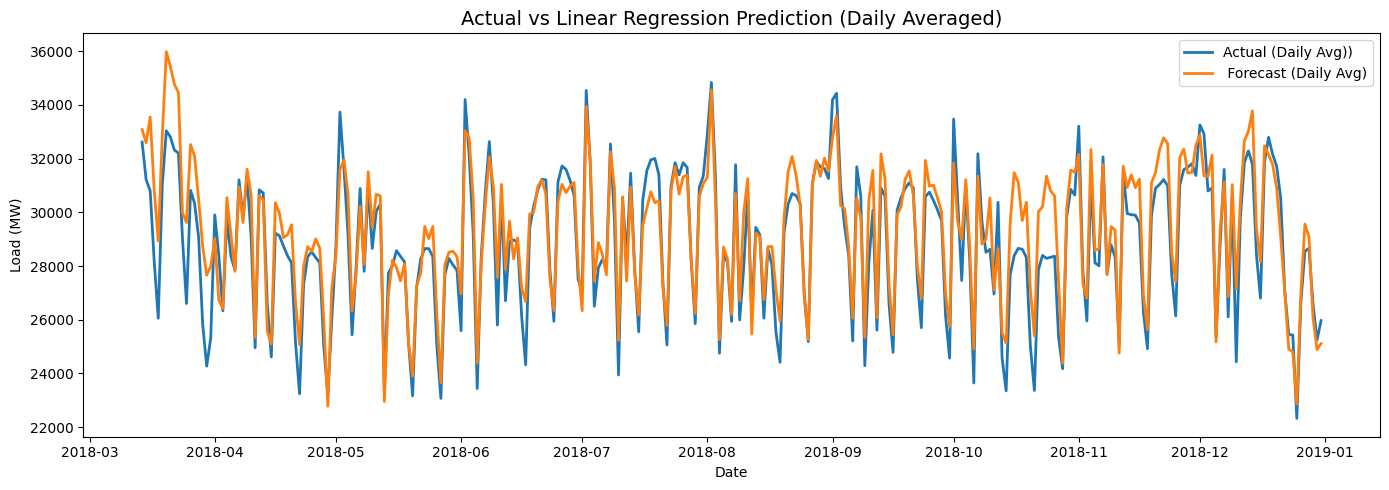

In [29]:
import matplotlib.pyplot as plt
import pandas as pd

# Build a temporary DataFrame for plotting
plot_df = pd.DataFrame({
    "time": df.index[split_index:],  # test period timestamps
    "actual": y_test.values,
    "pred": y_pred_lr
})

# Convert to daily averages
plot_daily = plot_df.resample('D', on='time').mean()

plt.figure(figsize=(14, 5))
plt.plot(plot_daily.index, plot_daily['actual'], label="Actual (Daily Avg))", linewidth=2)
plt.plot(plot_daily.index, plot_daily['pred'], label=" Forecast (Daily Avg)", linewidth=2)

plt.title("Actual vs Linear Regression Prediction (Daily Averaged)", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Load (MW)")
plt.legend()
plt.tight_layout()
plt.show()


# ARIMA

## Hourly Series

In [12]:
# target variable for univariate ARIMA
series = df['total load actual']


In [13]:
train_size = int(len(series) * 0.8)
train, test = series[:train_size], series[train_size:]


In [19]:
from statsmodels.tsa.arima.model import ARIMA
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Simple ARIMA(2,1,2) as a starting point
model = ARIMA(train, order=(2,1,2))
model_fit = model.fit()

# Forecast for the test period
forecast = model_fit.forecast(steps=len(test))

# Evaluate performance
mae  = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))
mape = np.mean(np.abs((test - forecast) / test)) * 100
r2   = r2_score(test, forecast)

print("📊 ARIMA Performance:")
print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")
print(f"R²  : {r2:.3f}")


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using

📊 ARIMA Performance:
MAE : 3990.29
RMSE: 4759.66
MAPE: 15.07%
R²  : -0.109


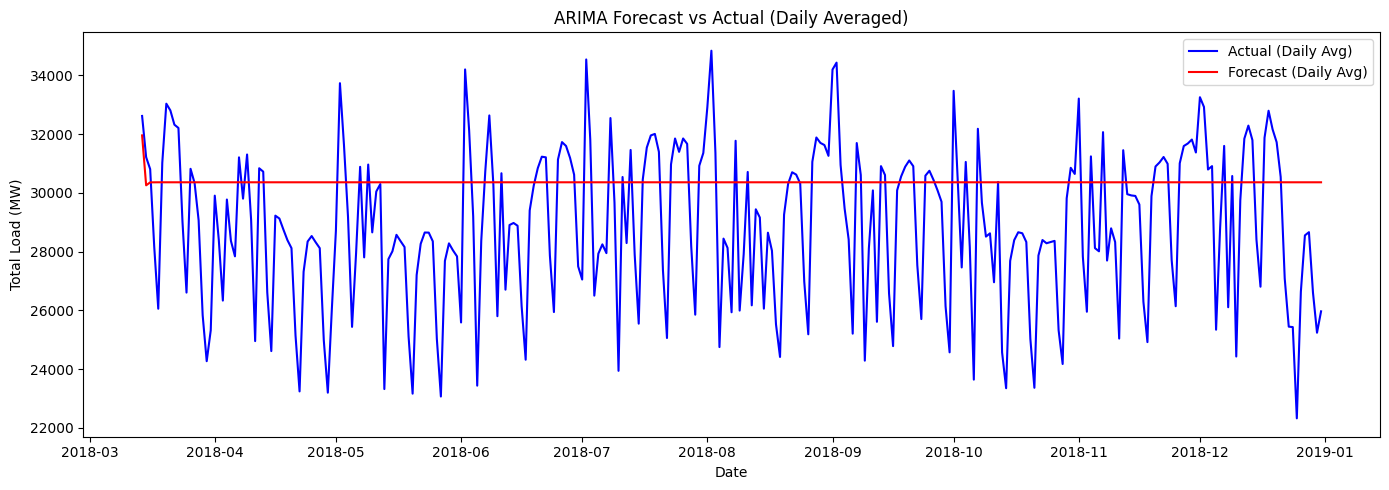

In [20]:
import matplotlib.pyplot as plt

# --- Convert test + forecast to daily mean ---
test_daily = test.resample('D').mean()
forecast_daily = pd.Series(forecast, index=test.index).resample('D').mean()

plt.figure(figsize=(14,5))
plt.plot(test_daily.index, test_daily, label='Actual (Daily Avg)', color='blue')
plt.plot(forecast_daily.index, forecast_daily, label='Forecast (Daily Avg)', color='red')

plt.title('ARIMA Forecast vs Actual (Daily Averaged)')
plt.xlabel('Date')
plt.ylabel('Total Load (MW)')
plt.legend()
plt.tight_layout()
plt.show()



# SARIMAX

In [21]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

model = SARIMAX(
    y_train,
    exog=X_train,
    order=(1,1,1),
    seasonal_order=(1,0,1,7),
    enforce_stationarity=False,
    enforce_invertibility=False
)
model_fit = model.fit(disp=False)


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [23]:
forecast = model_fit.forecast(steps=len(y_test), exog=X_test)

mae  = mean_absolute_error(y_test, forecast)
rmse = np.sqrt(mean_squared_error(y_test, forecast))
mape = np.mean(np.abs((y_test - forecast) / y_test)) * 100
r2   = r2_score(y_test, forecast)

print("\n📊 SARIMAX Performance:")
print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")
print(f"R²  : {r2:.3f}")



📊 SARIMAX Performance:
MAE : 2212.15
RMSE: 2600.47
MAPE: 8.26%
R²  : 0.669


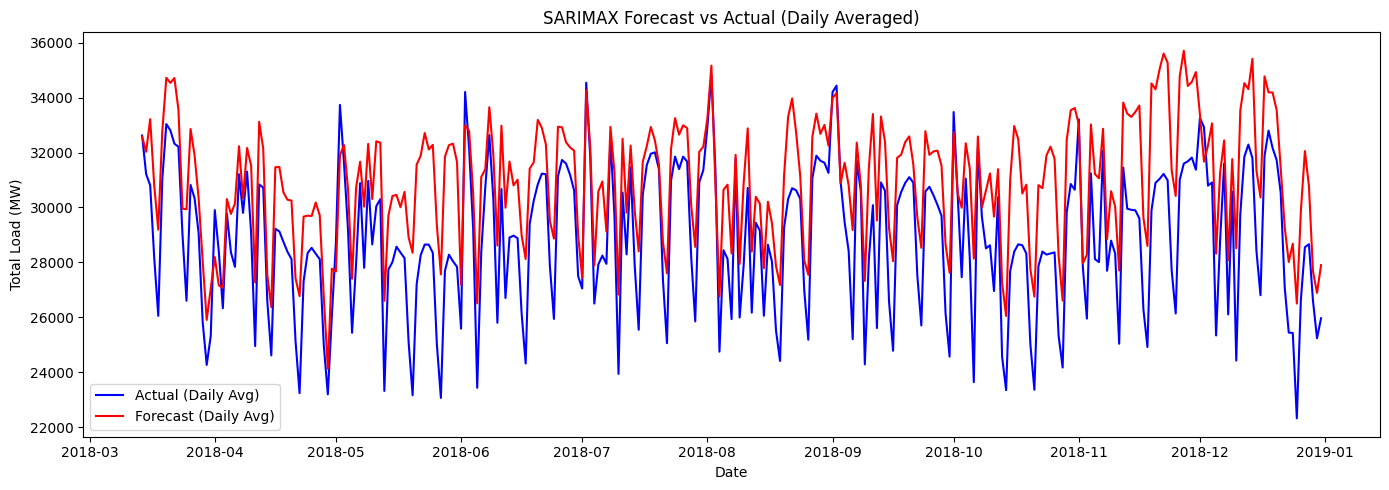

In [27]:
# Convert test and forecast to daily averages
test_daily = y_test.resample('D').mean()
forecast_daily = pd.Series(forecast, index=y_test.index).resample('D').mean()

plt.figure(figsize=(14,5))
plt.plot(test_daily.index, test_daily, label='Actual (Daily Avg)', color='blue')
plt.plot(forecast_daily.index, forecast_daily, label='Forecast (Daily Avg)', color='red')

plt.title('SARIMAX Forecast vs Actual (Daily Averaged)')
plt.xlabel('Date')
plt.ylabel('Total Load (MW)')
plt.legend()
plt.tight_layout()
plt.show()
